# MiniChefGPT

Train a Transformer to turn ingredient lists into a title and recipe steps. This notebook explains five mechanisms, saves the best model, reloads it, and tests custom ingredients.

Run from the project root with `requirements.txt`. Use the measured results and generated recipes below to assess quality.

## Setup

Set a reproducible seed and choose settings for this computer. The CPU profile has three Transformer blocks and a 256-token context. A larger GPU profile is available in the Python training script.

In [1]:
import ast
import hashlib
import html
import json
import math
import os
import random
import re
import sys
import time
import unicodedata
from dataclasses import asdict, dataclass
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
if not (PROJECT_ROOT / 'recipe_10000.csv').exists():
    candidate = PROJECT_ROOT.parent
    if (candidate / 'recipe_10000.csv').exists():
        PROJECT_ROOT = candidate
if (PROJECT_ROOT / '.runtime').exists():
    sys.path.insert(0, str(PROJECT_ROOT / '.runtime'))
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from tokenizers import Tokenizer, decoders, models, normalizers, pre_tokenizers, trainers

SPECIAL_TOKENS = ['<pad>', '<unk>', '<bos>', '<ingredients>', '<title>', '<step>', '<eos>']
IGNORE_INDEX = -100

@dataclass
class Config:
    seed: int = 42
    vocab_size: int = 4096
    context_length: int = 256
    d_model: int = 128
    num_heads: int = 4
    num_layers: int = 3
    d_ff: int = 384
    dropout: float = 0.1
    batch_size: int = 8
    learning_rate: float = 6e-4
    min_learning_rate: float = 6e-5
    weight_decay: float = 0.01
    max_steps: int = 12000
    training_minutes: float = 30.0
    eval_every: int = 300
    warmup_steps: int = 100
    patience: int = 6
    cpu_threads: int = 4


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def setup(config):
    seed_everything(config.seed)
    torch.set_num_threads(config.cpu_threads)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device} | CPU threads: {torch.get_num_threads()}')
    return device

In [2]:
config = Config(**{'seed': 42, 'vocab_size': 4096, 'context_length': 256, 'd_model': 128, 'num_heads': 4, 'num_layers': 3, 'd_ff': 384, 'dropout': 0.1, 'batch_size': 8, 'learning_rate': 0.0006, 'min_learning_rate': 6e-05, 'weight_decay': 0.01, 'max_steps': 12000, 'training_minutes': 30.0, 'eval_every': 300, 'warmup_steps': 100, 'patience': 6, 'cpu_threads': 4})
TRAIN_MODEL = True
RESUME_TRAINING = False
OUTPUT_DIR = PROJECT_ROOT / "models/refactored"
print(config)

Config(seed=42, vocab_size=4096, context_length=256, d_model=128, num_heads=4, num_layers=3, d_ff=384, dropout=0.1, batch_size=8, learning_rate=0.0006, min_learning_rate=6e-05, weight_decay=0.01, max_steps=12000, training_minutes=30.0, eval_every=300, warmup_steps=100, patience=6, cpu_threads=4)


## Recipe data

Read ingredient names, titles, and instruction steps. Remove empty and duplicate recipes, normalize text, and split recipes into training, validation, and test sets. Recipes with the same title stay together. Ingredient quantities do not align reliably with ingredient names in this source, so they are not paired automatically.

In [3]:
def clean_text(value):
    text = html.unescape(str(value))
    text = re.sub(r'<[^>]+>', ' ', text)
    text = unicodedata.normalize('NFKC', text).replace('\u00a0', ' ')
    return re.sub(r'\s+', ' ', text).strip().lower()


def parse_items(value):
    if isinstance(value, list):
        items = value
    elif pd.isna(value):
        items = []
    else:
        try:
            items = ast.literal_eval(str(value))
        except (ValueError, SyntaxError):
            items = [str(value)]
    if not isinstance(items, list):
        items = [str(items)]
    return [clean_text(item) for item in items if clean_text(item)]


def load_recipes(root=PROJECT_ROOT):
    source = root / 'recipe_10000.csv'
    frame = pd.read_csv(source)
    columns = {str(c).strip().lower(): c for c in frame.columns}
    def column(*names):
        return next((columns[name] for name in names if name in columns), None)
    title = column('name', 'title')
    ingredients = column('recipeingredientparts', 'ingredients')
    steps = column('recipeinstructions', 'steps', 'instructions')
    if any(c is None for c in (title, ingredients, steps)):
        raise ValueError('Dataset needs title, ingredients, and instruction columns.')
    rows = []
    seen_steps = set()
    for index, row in frame.iterrows():
        name = clean_text(row[title]) if pd.notna(row[title]) else ''
        items, instructions = parse_items(row[ingredients]), parse_items(row[steps])
        signature = hashlib.sha256(json.dumps(instructions).encode()).hexdigest()
        if not name or not items or not instructions or signature in seen_steps:
            continue
        seen_steps.add(signature)
        rows.append({'id': int(index), 'title': name, 'ingredients': items, 'steps': instructions})
    print(f'Read {len(frame):,} rows; kept {len(rows):,} recipes from {source.name}.')
    return rows


def split_recipes(rows, seed=42):
    # Identical titles remain together. Duplicate instructions were removed above.
    groups = {}
    for row in rows:
        groups.setdefault(row['title'], []).append(row)
    keys = sorted(groups)
    random.Random(seed).shuffle(keys)
    train_end, valid_end = int(len(keys) * 0.9), int(len(keys) * 0.95)
    def flatten(names):
        return [row for key in names for row in groups[key]]
    splits = {'train': flatten(keys[:train_end]), 'validation': flatten(keys[train_end:valid_end]),
              'test': flatten(keys[valid_end:])}
    print('Recipe split:', {name: len(values) for name, values in splits.items()})
    return splits


def recipe_prompt(ingredients):
    return '<bos><ingredients> ' + ', '.join(ingredients) + ' <title>'


def recipe_response(row):
    return ' ' + row['title'] + ''.join(' <step> ' + step for step in row['steps']) + ' <eos>'

## Subword tokenizer

Fit a byte-level subword tokenizer on training recipes only. Uncommon ingredient names can be represented without unknown whole words. Long recipes use multiple windows that repeat the ingredients; every response token is retained. Training also uses shuffled ingredient lists.

In [4]:
def train_tokenizer(rows, vocab_size=4096):
    tokenizer = Tokenizer(models.BPE(unk_token='<unk>'))
    tokenizer.normalizer = normalizers.Sequence([normalizers.NFKC(), normalizers.Lowercase()])
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tokenizer.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, min_frequency=2,
                                 special_tokens=SPECIAL_TOKENS,
                                 initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
                                 show_progress=False)
    tokenizer.train_from_iterator((recipe_prompt(r['ingredients']) + recipe_response(r) for r in rows),
                                  trainer=trainer)
    print(f'Train-only subword vocabulary: {tokenizer.get_vocab_size():,}')
    return tokenizer


class RecipeDataset:
    """Keep every response token, including later steps of long recipes.

    Each window repeats its ingredient prompt. A short response prefix provides
    continuity; only new title/instruction tokens contribute to the loss.
    """
    def __init__(self, rows, tokenizer, context_length, augment=False, seed=42):
        self.samples = []
        self.long_recipes = 0
        self.response_tokens = 0
        self.context_length = context_length
        rng = random.Random(seed)
        for row in rows:
            response = tokenizer.encode(recipe_response(row)).ids
            self.response_tokens += len(response)
            variants = [row['ingredients']]
            if augment and len(row['ingredients']) > 1:
                shuffled = list(row['ingredients'])
                rng.shuffle(shuffled)
                variants.append(shuffled)
            for variant_index, ingredients in enumerate(variants):
                prompt = tokenizer.encode(recipe_prompt(ingredients)).ids
                if len(prompt) > context_length // 2:
                    raise ValueError('Ingredient prompt exceeds half the context; increase context_length.')
                if variant_index == 0 and len(prompt) + len(response) > context_length + 1:
                    self.long_recipes += 1
                offset = 0
                while offset < len(response):
                    previous_budget = min(32, context_length - len(prompt))
                    previous = response[max(0, offset - previous_budget):offset]
                    prefix = prompt + previous
                    capacity = context_length + 1 - len(prefix)
                    chunk = response[offset:offset + capacity]
                    sequence = prefix + chunk
                    labels = [IGNORE_INDEX] * len(prefix) + chunk
                    self.samples.append((sequence[:-1], labels[1:]))
                    offset += len(chunk)
        self.lengths = np.array([len(x) for x, _ in self.samples])
        # Buckets reduce padding work. All examples remain equally likely.
        ordered = np.argsort(self.lengths)
        self.buckets = [a.tolist() for a in np.array_split(ordered, max(1, len(ordered) // 128)) if len(a)]
        self.bucket_probabilities = np.array([len(b) for b in self.buckets], dtype=float)
        self.bucket_probabilities /= self.bucket_probabilities.sum()

    def __len__(self):
        return len(self.samples)

    def batch(self, indices, pad_id, device):
        selected = [self.samples[int(i)] for i in indices]
        length = max(len(x) for x, _ in selected)
        x = torch.full((len(selected), length), pad_id, dtype=torch.long)
        y = torch.full_like(x, IGNORE_INDEX)
        for i, (tokens, labels) in enumerate(selected):
            x[i, :len(tokens)] = torch.tensor(tokens)
            y[i, :len(labels)] = torch.tensor(labels)
        return x.to(device), y.to(device)

    def random_batch(self, batch_size, pad_id, device):
        bucket = self.buckets[np.random.choice(len(self.buckets), p=self.bucket_probabilities)]
        return self.batch(np.random.choice(bucket, batch_size), pad_id, device)

## 1. Word and position embeddings

Mechanism 1: add a learned token embedding to a learned position embedding. Tokens are subword pieces rather than whole words. Both embeddings are updated during training.

In [5]:
class WordPositionEmbedding(nn.Module):
    """Learn a subword vector and an absolute position vector for each token."""
    def __init__(self, vocab_size, d_model, context_length, dropout=0.1):
        super().__init__()
        self.words = nn.Embedding(vocab_size, d_model)
        self.positions = nn.Embedding(context_length, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token_ids):
        positions = torch.arange(token_ids.size(1), device=token_ids.device)
        return self.dropout(self.words(token_ids) + self.positions(positions))

## 2. Layer normalization

Mechanism 2: normalize each token across its feature dimension before attention and before the feed-forward network.

In [6]:
class LayerNormalization(nn.Module):
    """Normalize the feature dimension independently at each token."""
    def __init__(self, d_model):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        return self.norm(x)

## 3. Causal attention

Mechanism 3: split queries, keys, and values into attention heads. Attention computes softmax(QKᵀ / √d) V with a causal mask, so a position cannot see future tokens. The PyTorch kernel implements this efficiently.

In [7]:
class CausalAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        if d_model % num_heads:
            raise ValueError('d_model must be divisible by num_heads')
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.projection = nn.Linear(d_model, d_model)
        self.dropout = dropout

    def forward(self, x):
        batch, length, width = x.shape
        qkv = self.qkv(x).reshape(batch, length, 3, self.num_heads, self.head_dim)
        query, key, value = qkv.permute(2, 0, 3, 1, 4).unbind(0)
        # Implements softmax(Q K^T / sqrt(head_dim) + causal_mask) V.
        # PyTorch's kernel avoids allocating unnecessary attention buffers.
        attention = F.scaled_dot_product_attention(
            query, key, value, is_causal=True,
            dropout_p=self.dropout if self.training else 0.0)
        attention = attention.transpose(1, 2).contiguous().reshape(batch, length, width)
        return self.projection(attention)

## 4. Feed-forward network

Mechanism 4: apply Linear → GELU → Dropout → Linear independently to each token. This changes token features without mixing sequence positions.

In [8]:
class FeedForward(nn.Module):
    """Apply the same two-layer network separately to every token."""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.network = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(d_ff, d_model))

    def forward(self, x):
        return self.network(x)

## 5. Residual connections

Mechanism 5: add each sublayer update to its input. Each block has two skip paths: x = x + Dropout(Attention(LayerNorm(x))), then x = x + Dropout(FFN(LayerNorm(x))).

In [9]:
class ResidualConnection(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, update):
        if x.shape != update.shape:
            raise ValueError('Residual tensors must have equal shapes')
        return x + self.dropout(update)

## Recipe Transformer

Combine the five mechanisms into a causal language model. The output projection shares the token embedding weights. Training predicts the next title or instruction token; ingredient prompt and padding positions do not contribute to the loss.

In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention_norm = LayerNormalization(config.d_model)
        self.ffn_norm = LayerNormalization(config.d_model)
        self.attention = CausalAttention(config.d_model, config.num_heads, config.dropout)
        self.ffn = FeedForward(config.d_model, config.d_ff, config.dropout)
        self.attention_residual = ResidualConnection(config.dropout)
        self.ffn_residual = ResidualConnection(config.dropout)

    def forward(self, x):
        x = self.attention_residual(x, self.attention(self.attention_norm(x)))
        return self.ffn_residual(x, self.ffn(self.ffn_norm(x)))


class MiniChefGPT(nn.Module):
    def __init__(self, config, vocab_size):
        super().__init__()
        self.config = config
        self.embedding = WordPositionEmbedding(vocab_size, config.d_model, config.context_length, config.dropout)
        self.blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.num_layers)])
        self.final_norm = LayerNormalization(config.d_model)
        self.head = nn.Linear(config.d_model, vocab_size, bias=False)
        # Sharing weights saves parameters and improves data efficiency.
        self.head.weight = self.embedding.words.weight
        self.apply(self._initialize)

    @staticmethod
    def _initialize(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, token_ids, targets=None, last_only=False):
        if token_ids.size(1) > self.config.context_length:
            raise ValueError('Input is longer than the configured context')
        hidden = self.embedding(token_ids)
        for block in self.blocks:
            hidden = block(hidden)
        hidden = self.final_norm(hidden)
        if targets is not None:
            valid = targets != IGNORE_INDEX
            # Do not project ingredient prompt/padding tokens into the vocabulary.
            logits = self.head(hidden[valid])
            return F.cross_entropy(logits, targets[valid], reduction='sum'), valid.sum()
        return self.head(hidden[:, -1:] if last_only else hidden)

## Training and evaluation

Use AdamW, learning-rate warmup and decay, gradient clipping, and validation-based checkpoint selection. Validation and test loss are ordinary, unweighted cross-entropy over every response token. Perplexity is exp(loss). The latest checkpoint includes optimizer and random states for resuming.

In [11]:
@torch.inference_mode()
def evaluate(model, dataset, batch_size, pad_id, device):
    was_training = model.training
    model.eval()
    total_loss, total_tokens = 0.0, 0
    # Every held-out response token is scored exactly once; no random test batches.
    ordered = np.argsort(dataset.lengths)
    for start in range(0, len(ordered), batch_size):
        x, y = dataset.batch(ordered[start:start + batch_size], pad_id, device)
        loss_sum, tokens = model(x, y)
        total_loss += loss_sum.item()
        total_tokens += tokens.item()
    model.train(was_training)
    nll = total_loss / total_tokens
    return {'loss': nll, 'perplexity': math.exp(min(nll, 50)), 'tokens': total_tokens}


def atomic_save(payload, path):
    temporary = path.with_suffix('.tmp')
    torch.save(payload, temporary)
    temporary.replace(path)


def model_payload(model, tokenizer, config, step, best_loss, manifest):
    return {'format_version': 2, 'model_state_dict': model.state_dict(),
            'config': asdict(config), 'tokenizer_json': tokenizer.to_str(),
            'step': step, 'best_validation_loss': best_loss, 'data_manifest': manifest}


def train_model(model, datasets, tokenizer, config, device, output_dir, manifest, resume=False):
    output_dir.mkdir(parents=True, exist_ok=True)
    pad_id = tokenizer.token_to_id('<pad>')
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate,
                                  weight_decay=config.weight_decay)
    history, start_step, best_loss, stale = [], 0, math.inf, 0
    latest_path, best_path = output_dir / 'minichefgpt_last.pt', output_dir / 'minichefgpt_best.pt'
    elapsed_before = 0.0
    if resume:
        checkpoint = torch.load(latest_path, map_location=device, weights_only=False)
        if checkpoint['tokenizer_json'] != tokenizer.to_str() or checkpoint['data_manifest'] != manifest:
            raise ValueError('Resume data/tokenizer differs from the checkpoint')
        architecture_fields = ('vocab_size', 'context_length', 'd_model', 'num_heads', 'num_layers', 'd_ff', 'dropout')
        if any(checkpoint['config'][key] != getattr(config, key) for key in architecture_fields):
            raise ValueError('Resume architecture differs from the checkpoint')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_step, best_loss = checkpoint['step'], checkpoint['best_validation_loss']
        history = checkpoint['history']
        random.setstate(checkpoint['python_rng'])
        np.random.set_state(checkpoint['numpy_rng'])
        torch.set_rng_state(checkpoint['torch_rng'].cpu())
        if device.type == 'cuda' and checkpoint.get('cuda_rng') is not None:
            torch.cuda.set_rng_state_all(checkpoint['cuda_rng'])
        elapsed_before = checkpoint.get('elapsed_seconds', 0.0)
        stale = checkpoint.get('stale_evaluations', 0)
        print(f'Resuming at step {start_step}; each run has its own time budget.')
    if start_step >= config.max_steps:
        raise ValueError('Increase max_steps beyond the saved step before resuming')
    start = time.monotonic()
    last_report = start
    running_loss, running_tokens = 0.0, 0
    stop_reason = 'max_steps'
    for step in range(start_step + 1, config.max_steps + 1):
        model.train()
        x, y = datasets['train'].random_batch(config.batch_size, pad_id, device)
        if step <= config.warmup_steps:
            lr = config.learning_rate * step / config.warmup_steps
        else:
            progress = min(1.0, (step - config.warmup_steps) / max(1, config.max_steps - config.warmup_steps))
            lr = config.min_learning_rate + 0.5 * (config.learning_rate - config.min_learning_rate) * (1 + math.cos(math.pi * progress))
        for group in optimizer.param_groups:
            group['lr'] = lr
        optimizer.zero_grad(set_to_none=True)
        loss_sum, tokens = model(x, y)
        loss = loss_sum / tokens
        if not torch.isfinite(loss):
            raise FloatingPointError('Non-finite training loss')
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss_sum.item()
        running_tokens += tokens.item()
        elapsed = time.monotonic() - start
        budget_reached = config.training_minutes > 0 and elapsed >= config.training_minutes * 60
        if step == 1 or time.monotonic() - last_report >= 30:
            print(f'Step {step:5d} | loss {loss.item():.3f} | {elapsed / 60:.1f} min', flush=True)
            last_report = time.monotonic()
        check = step % config.eval_every == 0 or step == config.max_steps or budget_reached
        if check:
            validation = evaluate(model, datasets['validation'], config.batch_size, pad_id, device)
            item = {'step': step, 'train_loss': running_loss / running_tokens,
                    'validation_loss': validation['loss'], 'validation_perplexity': validation['perplexity'],
                    'learning_rate': lr, 'elapsed_seconds': elapsed_before + time.monotonic() - start}
            history.append(item)
            running_loss, running_tokens = 0.0, 0
            print(f"Validation | step {step} | loss {validation['loss']:.4f} | perplexity {validation['perplexity']:.2f}", flush=True)
            if validation['loss'] < best_loss - 1e-4:
                best_loss, stale = validation['loss'], 0
                atomic_save(model_payload(model, tokenizer, config, step, best_loss, manifest), best_path)
            else:
                stale += 1
            latest = model_payload(model, tokenizer, config, step, best_loss, manifest)
            latest.update(optimizer_state_dict=optimizer.state_dict(), history=history, stale_evaluations=stale,
                          python_rng=random.getstate(), numpy_rng=np.random.get_state(),
                          torch_rng=torch.get_rng_state(),
                          cuda_rng=torch.cuda.get_rng_state_all() if device.type == 'cuda' else None,
                          elapsed_seconds=elapsed_before + time.monotonic() - start)
            atomic_save(latest, latest_path)
            (output_dir / 'training_history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')
            if budget_reached or stale >= config.patience:
                stop_reason = 'time_budget' if budget_reached else 'early_stopping'
                break
    if not best_path.exists():
        raise ValueError('No training steps were executed; increase max_steps when resuming')
    best = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(best['model_state_dict'])
    print(f"Loaded best step {best['step']} | stop: {stop_reason}")
    return history, {'best_step': best['step'], 'last_step': step, 'stop_reason': stop_reason,
                     'elapsed_seconds': elapsed_before + time.monotonic() - start}


def load_model(path, device='cpu'):
    # Load only locally produced/trusted checkpoints.
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    config = Config(**checkpoint['config'])
    tokenizer = Tokenizer.from_str(checkpoint['tokenizer_json'])
    model = MiniChefGPT(config, tokenizer.get_vocab_size()).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model, tokenizer, config

## Generate a recipe

Generate a short title followed by steps. Temperature, top-k/top-p sampling, and a sign-aware repetition penalty control decoding. Several candidates are ranked by requested-ingredient mentions. This score does not establish correctness or ingredient exclusivity.

In [12]:
def ingredient_coverage(ingredients, text):
    def forms(word):
        exceptions = {'potatoes': 'potato', 'tomatoes': 'tomato', 'leaves': 'leaf', 'knives': 'knife'}
        singular = exceptions.get(word, word[:-1] if word.endswith('s') and not word.endswith('ss') else word)
        if word.endswith('ies'):
            singular = word[:-3] + 'y'
        return {word, singular, singular + 's'}
    output = set().union(*(forms(word) for word in re.findall(r'[a-z]+', text.lower())))
    matched = []
    for ingredient in ingredients:
        terms = [w for w in re.findall(r'[a-z]+', ingredient.lower()) if w not in {'fresh', 'ground', 'dried', 'chopped'}]
        if terms and all(forms(term) & output for term in terms):
            matched.append(ingredient)
    return len(matched) / max(1, len(ingredients)), matched


@torch.inference_mode()
def sample_recipe(model, tokenizer, ingredients, max_new_tokens=220, temperature=0.75,
                  top_p=0.9, top_k=40, repetition_penalty=1.12, seed=42):
    if not 0 < temperature or not 0 < top_p <= 1 or top_k < 1 or repetition_penalty < 1:
        raise ValueError('Invalid sampling settings')
    if isinstance(ingredients, str):
        ingredients = [part.strip() for part in ingredients.split(',') if part.strip()]
    ingredients = [clean_text(item) for item in ingredients if clean_text(item)]
    if not ingredients or len(ingredients) > 30:
        raise ValueError('Provide between 1 and 30 ingredient names')
    prompt = tokenizer.encode(recipe_prompt(ingredients)).ids
    if len(prompt) > model.config.context_length // 2:
        raise ValueError('Ingredient list is too long for this model context')
    device = next(model.parameters()).device
    rng = torch.Generator(device=device).manual_seed(seed)
    was_training = model.training
    model.eval()
    generated, finished = [], False
    eos, step_id = tokenizer.token_to_id('<eos>'), tokenizer.token_to_id('<step>')
    blocked = [tokenizer.token_to_id(t) for t in SPECIAL_TOKENS if t not in {'<step>', '<eos>'}]
    for _ in range(max_new_tokens):
        # Keep the full ingredient condition even after the response grows long.
        available = model.config.context_length - len(prompt)
        context = prompt + generated[-available:]
        logits = model(torch.tensor([context], device=device), last_only=True)[0, -1].clone()
        logits /= temperature
        for token in set(generated[-32:]):
            if token not in (eos, step_id):
                logits[token] = logits[token] / repetition_penalty if logits[token] > 0 else logits[token] * repetition_penalty
        logits[blocked] = -torch.inf
        if step_id not in generated:
            logits[eos] = -torch.inf
        if len(generated) >= 18 and step_id not in generated:
            logits.fill_(-torch.inf)
            logits[step_id] = 0
        values, indices = torch.topk(logits, min(top_k, logits.numel()))
        probabilities = F.softmax(values, dim=-1)
        remove = probabilities.cumsum(0) - probabilities > top_p
        values[remove] = -torch.inf
        selected = torch.multinomial(F.softmax(values, dim=-1), 1, generator=rng)
        token = indices[selected].item()
        generated.append(token)
        if token == eos:
            finished = True
            break
    model.train(was_training)
    sections, current = [], []
    for token in generated:
        if token in (step_id, eos):
            sections.append(tokenizer.decode(current).strip())
            current = []
        else:
            current.append(token)
    if current:
        sections.append(tokenizer.decode(current).strip())
    title = sections[0] if sections else ''
    steps = [part for part in sections[1:] if part]
    coverage, matched = ingredient_coverage(ingredients, ' '.join(steps))
    return {'title': title, 'ingredients': ingredients, 'steps': steps,
            'ingredient_coverage': coverage, 'mentioned_ingredients': matched,
            'generated_tokens': len(generated), 'finished': finished}


def generate_recipe(model, tokenizer, ingredients, candidates=8, seed=42, **settings):
    if candidates < 1:
        raise ValueError('candidates must be positive')
    recipes = [sample_recipe(model, tokenizer, ingredients, seed=seed + i, **settings) for i in range(candidates)]
    # Prefer ingredient mentions, an EOS boundary, and nonempty instruction steps.
    return max(recipes, key=lambda r: (r['ingredient_coverage'], bool(r['steps']), r['finished']))


def print_recipe(recipe):
    print('Title:', recipe['title'] or '(no title generated)')
    print('Ingredients:', ', '.join(recipe['ingredients']))
    for number, step in enumerate(recipe['steps'], 1):
        print(f'{number}. {step}')
    print(f"Ingredient mentions: {recipe['ingredient_coverage']:.0%} | EOS: {recipe['finished']}")

## Prepare training

Prepare the datasets and define four custom ingredient tests. Reusing a checkpoint also reuses its tokenizer, configuration, and data split. The final test set is used after checkpoint selection. Save metrics and actual neural outputs, including whether generation reached the end marker.

In [13]:
def prepare(config, root=PROJECT_ROOT, tokenizer=None):
    device = setup(config)
    rows = load_recipes(root)
    splits = split_recipes(rows, config.seed)
    if tokenizer is None:
        tokenizer = train_tokenizer(splits['train'], config.vocab_size)
    datasets = {name: RecipeDataset(values, tokenizer, config.context_length,
                                    augment=name == 'train', seed=config.seed)
                for name, values in splits.items()}
    manifest = {'seed': config.seed,
                'data_sha256': hashlib.sha256(json.dumps(rows, sort_keys=True).encode()).hexdigest(),
                'recipe_ids': {name: [row['id'] for row in values] for name, values in splits.items()},
                'recipe_counts': {name: len(values) for name, values in splits.items()},
                'window_counts': {name: len(values) for name, values in datasets.items()},
                'long_recipes': {name: values.long_recipes for name, values in datasets.items()},
                'truncated_response_tokens': 0}
    model = MiniChefGPT(config, tokenizer.get_vocab_size()).to(device)
    print('Parameters:', f'{sum(p.numel() for p in model.parameters()):,}')
    print('Long recipes retained as multiple windows:', manifest['long_recipes'])
    return device, splits, tokenizer, datasets, manifest, model


def prepare_saved_model(path, root=PROJECT_ROOT):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    saved_model, tokenizer, config = load_model(path, device)
    device, splits, tokenizer, datasets, manifest, _ = prepare(config, root, tokenizer=tokenizer)
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    if checkpoint['data_manifest'] != manifest:
        raise ValueError('Dataset changed since training; use the saved model for inference or retrain before evaluation')
    return device, splits, tokenizer, datasets, manifest, saved_model


CUSTOM_INGREDIENTS = {
    'Chicken dinner': ['chicken', 'garlic', 'onion', 'tomato'],
    'Vegetable pasta': ['pasta', 'tomato', 'garlic', 'basil'],
    'Cheese omelet': ['eggs', 'cheese', 'onion', 'spinach'],
    'Roasted vegetables': ['potatoes', 'carrots', 'olive oil', 'rosemary'],
}


def evaluate_generation(model, tokenizer, rows, sample_count=12, seed=42):
    """A fixed held-out generation sample complements teacher-forced perplexity."""
    eligible = [row for row in rows if len(row['ingredients']) <= 12
                and len(tokenizer.encode(recipe_prompt(row['ingredients'])).ids) <= model.config.context_length // 2]
    chosen = random.Random(seed).sample(eligible, min(sample_count, len(eligible)))
    outputs = []
    for index, row in enumerate(chosen):
        recipe = generate_recipe(model, tokenizer, row['ingredients'], candidates=1,
                                 seed=seed + index, max_new_tokens=220)
        outputs.append({'recipe_id': row['id'], 'reference_title': row['title'], **recipe})
    return {'sample_count': len(outputs), 'candidates_per_input': 1,
            'selection': 'seeded sample of held-out recipes with at most 12 ingredients',
            'mean_ingredient_coverage': float(np.mean([r['ingredient_coverage'] for r in outputs])),
            'eos_rate': float(np.mean([r['finished'] for r in outputs])),
            'nonempty_steps_rate': float(np.mean([bool(r['steps']) for r in outputs]))}, outputs


def finish_run(model, tokenizer, config, device, datasets, manifest, history, run, output_dir, test_rows=None):
    # Reload from disk before testing so the artifact, not an in-memory model, is tested.
    saved_model, saved_tokenizer, _ = load_model(output_dir / 'minichefgpt_best.pt', device)
    test = evaluate(saved_model, datasets['test'], config.batch_size, tokenizer.token_to_id('<pad>'), device)
    validation = evaluate(saved_model, datasets['validation'], config.batch_size, tokenizer.token_to_id('<pad>'), device)
    print(f"Test loss: {test['loss']:.4f} | Test perplexity: {test['perplexity']:.2f}", flush=True)
    custom = {}
    for index, (name, ingredients) in enumerate(CUSTOM_INGREDIENTS.items()):
        print('\n' + name, flush=True)
        recipe = generate_recipe(saved_model, saved_tokenizer, ingredients, seed=config.seed + 10 * index)
        print_recipe(recipe)
        custom[name] = recipe
    generation_benchmark = None
    if test_rows is not None:
        print('Evaluating 12 unseen ingredient lists...', flush=True)
        generation_benchmark, heldout_outputs = evaluate_generation(saved_model, saved_tokenizer, test_rows, seed=config.seed)
        (output_dir / 'heldout_generation.json').write_text(json.dumps(heldout_outputs, indent=2), encoding='utf-8')
        print('Held-out generation:', generation_benchmark, flush=True)
    metrics = {'run': run, 'config': asdict(config), 'parameters': sum(p.numel() for p in model.parameters()),
               'validation': validation, 'test': test, 'data': manifest, 'generation_benchmark': generation_benchmark,
               'mean_custom_ingredient_coverage': float(np.mean([r['ingredient_coverage'] for r in custom.values()])),
               'custom_eos_rate': float(np.mean([r['finished'] for r in custom.values()])),
               'quality_note': 'Ingredient mentions and perplexity do not measure recipe correctness. Inspect neural drafts.'}
    tokenizer.save(str(output_dir / 'tokenizer.json'))
    (output_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
    (output_dir / 'custom_recipes.json').write_text(json.dumps(custom, indent=2), encoding='utf-8')
    return metrics, custom

## Prepare the model

Build the train-only tokenizer, datasets, and Transformer. When reusing a saved model, load its exact tokenizer and settings before building datasets. The saved data manifest verifies that the held-out split is unchanged.

In [14]:
if TRAIN_MODEL:
    device, splits, tokenizer, datasets, manifest, model = prepare(config)
else:
    device, splits, tokenizer, datasets, manifest, model = prepare_saved_model(
        OUTPUT_DIR / "minichefgpt_best.pt")
    config = model.config
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Response tokens discarded:", manifest["truncated_response_tokens"])

Device: cpu | CPU threads: 4
Read 10,000 rows; kept 9,979 recipes from recipe_10000.csv.
Recipe split: {'train': 8983, 'validation': 502, 'test': 494}
Parameters: 1,053,440
Long recipes retained as multiple windows: {'train': 853, 'validation': 46, 'test': 50}
Response tokens discarded: 0


## Train and save

Train within the time budget above. The best validation checkpoint is `models/refactored/minichefgpt_best.pt`; the resumable checkpoint is `minichefgpt_last.pt`. Set `TRAIN_MODEL = False` to reuse the saved model. Set `RESUME_TRAINING = True` and increase `max_steps` to continue training.

In [15]:
if TRAIN_MODEL:
    history, run = train_model(model, datasets, tokenizer, config, device,
                               OUTPUT_DIR, manifest, resume=RESUME_TRAINING)
else:
    history = json.loads((OUTPUT_DIR / "training_history.json").read_text(encoding="utf-8"))
    run = json.loads((OUTPUT_DIR / "metrics.json").read_text(encoding="utf-8"))["run"]
print("Best checkpoint:", OUTPUT_DIR / "minichefgpt_best.pt")

Step     1 | loss 8.333 | 0.0 min
Step    85 | loss 5.554 | 0.5 min
Step   171 | loss 4.225 | 1.0 min
Step   270 | loss 4.351 | 1.5 min
Validation | step 300 | loss 4.1933 | perplexity 66.24
Step   332 | loss 4.456 | 2.0 min
Step   419 | loss 3.905 | 2.5 min
Step   505 | loss 3.882 | 3.0 min
Step   596 | loss 3.640 | 3.5 min
Validation | step 600 | loss 3.7910 | perplexity 44.30
Step   676 | loss 3.024 | 4.0 min
Step   765 | loss 4.176 | 4.5 min
Step   858 | loss 2.794 | 5.0 min
Validation | step 900 | loss 3.5538 | perplexity 34.95
Step   927 | loss 3.556 | 5.5 min
Step  1013 | loss 4.013 | 6.0 min
Step  1101 | loss 3.446 | 6.5 min
Step  1189 | loss 3.710 | 7.0 min
Validation | step 1200 | loss 3.3963 | perplexity 29.85
Step  1268 | loss 3.778 | 7.5 min
Step  1357 | loss 3.222 | 8.0 min
Step  1443 | loss 3.156 | 8.5 min
Validation | step 1500 | loss 3.3096 | perplexity 27.37
Step  1525 | loss 3.867 | 9.0 min
Step  1615 | loss 2.980 | 9.6 min
Step  1735 | loss 2.940 | 10.1 min
Validati

## Test the saved model

Reload the checkpoint from disk, evaluate all held-out test response tokens, and test chicken dinner, pasta, an omelet, and vegetables. Also generate recipes for 12 unseen test ingredient lists. These are actual neural outputs; no retrieved recipe or template is substituted.

In [16]:
metrics, custom_recipes = finish_run(model, tokenizer, config, device, datasets,
                                   manifest, history, run, OUTPUT_DIR, test_rows=splits['test'])

Test loss: 2.8143 | Test perplexity: 16.68

Chicken dinner
Title: easy chicken
Ingredients: chicken, garlic, onion, tomato
1. combine all ingredients in a large bowl.
2. dip chicken pieces into melted butter mixture.
3. place chicken in buttered baking dish.
4. bake at 350 degrees for 15 minutes or until done.
Ingredient mentions: 25% | EOS: True

Vegetable pasta
Title: tomato sauce
Ingredients: pasta, tomato, garlic, basil
1. melt butter in a large heavy saucepan.
2. add garlic and saute for 3 minutes or until cooked.
3. add garlic, tomato sauce, basil, basil, oregano and pepper.
4. cover and cook over low heat until liquid thickens.
5. reduce heat, cook for 10 minutes or until pasta is tender, stirring occasionally.
6. meanwhile, combine remaining ingredients and sprinkle with parmesan cheese.
7. sprinkle with mozzarella and top of parmesan.
8. serve immediately.
Ingredient mentions: 100% | EOS: True

Cheese omelet
Title: creamy spinach stuffed spinach
Ingredients: eggs, cheese, onio

## Training results

Compare training and validation loss at each evaluation checkpoint. Test perplexity measures token prediction. Inspect custom recipes to see whether the model follows the requested ingredients.

     split     loss  perplexity  tokens
validation 2.766026   15.895347   65654
      test 2.814280   16.681153   64382
Best training step: 5933
Held-out generation: {'sample_count': 12, 'candidates_per_input': 1, 'selection': 'seeded sample of held-out recipes with at most 12 ingredients', 'mean_ingredient_coverage': 0.2746693121693122, 'eos_rate': 1.0, 'nonempty_steps_rate': 1.0}
Custom ingredient coverage: 56%


MiniChefGPT_combined.ipynb:cell17:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


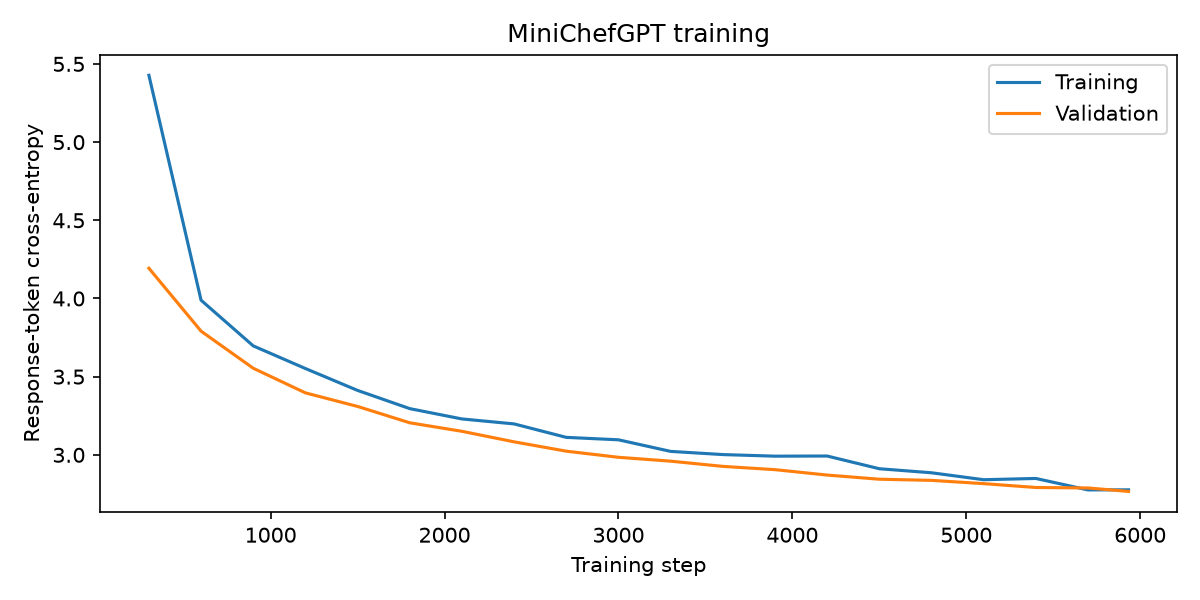

In [17]:
import matplotlib.pyplot as plt
summary = pd.DataFrame([{"split": name, **metrics[name]} for name in ("validation", "test")])
print(summary.to_string(index=False))
print("Best training step:", metrics["run"]["best_step"])
print("Held-out generation:", metrics["generation_benchmark"])
print("Custom ingredient coverage:", "{:.0%}".format(metrics["mean_custom_ingredient_coverage"]))
plot_data = pd.DataFrame(history)
plt.figure(figsize=(8, 4))
plt.plot(plot_data["step"], plot_data["train_loss"], label="Training")
plt.plot(plot_data["step"], plot_data["validation_loss"], label="Validation")
plt.xlabel("Training step")
plt.ylabel("Response-token cross-entropy")
plt.title("MiniChefGPT training")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_loss.png", dpi=150)
plt.show()
plt.close()

## Your ingredients

Edit this list and rerun the cell. Loading a saved model does not require retraining. The result includes a title, steps, ingredient mentions, and whether the recipe reached its end marker.

In [18]:
recipe_model, recipe_tokenizer, saved_config = load_model(OUTPUT_DIR / "minichefgpt_best.pt", device)
my_ingredients = ["chicken", "garlic", "onion", "tomato"]
my_recipe = generate_recipe(recipe_model, recipe_tokenizer, my_ingredients, seed=123)
print_recipe(my_recipe)

Title: chicken soup
Ingredients: chicken, garlic, onion, tomato
1. cook broccoli, onion and garlic until tender.
2. drain.
3. add rice, salt and pepper.
4. cook for 15 minutes.
5. stir in chicken broth and stir well.
6. cover and bake at 350 degrees for 30 minutes or until noodles are tender, stirring occasionally.
Ingredient mentions: 75% | EOS: True


## What the results mean

A small model trained from scratch can learn recipe language without consistently planning a usable meal. Ingredient mentions do not prove that all requested ingredients are used or that extra ingredients are absent. The source data sometimes mentions ingredients missing from its own list. Assess quality using the saved outputs as well as held-out loss. Longer training and a larger GPU model are supported; measure improvements on validation data and new ingredient tests. Earlier weighted-loss results are not directly comparable to this unweighted, response-only evaluation.